# Baselines: HAR and LSTM

Calls `src/models.py` and `src/train.py` functions. No logic lives here.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))
import config
from src.models import HARModel, HARPooled, LSTMModel, compute_har_features, prepare_har_arrays
from src.train import set_seeds, train_lstm

## HAR Baselines

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from src.models import compute_har_features, prepare_har_arrays

weekly_rv = pd.read_parquet(Path(config.DATA_RAW_DIR) / "weekly_rv.parquet")
target    = pd.read_parquet(Path(config.DATA_FEATURES_DIR) / "target.parquet")
splits    = pd.read_parquet(Path(config.DATA_FEATURES_DIR) / "splits.parquet")
print(f"weekly_rv: {weekly_rv.shape}, target: {target.shape}, splits: {splits.shape}")

weekly_rv: (573, 465), target: (572, 465), splits: (572, 2)


In [3]:
rv_1w, rv_4w, rv_13w = compute_har_features(weekly_rv)
print(f"RV_13w grand mean (excl. NaN): {rv_13w.stack().mean():.4f}")
print(f"NaN weeks at start (rv_13w): {rv_13w.isna().all(axis=1).sum()}")

RV_13w grand mean (excl. NaN): 0.2530
NaN weeks at start (rv_13w): 12


In [4]:
X_train, y_train, Xp_train, yp_train, train_idx = prepare_har_arrays(
    rv_1w, rv_4w, rv_13w, target, splits, "train"
)
X_val, y_val, Xp_val, yp_val, val_idx = prepare_har_arrays(
    rv_1w, rv_4w, rv_13w, target, splits, "val"
)
print(f"Train: {len(train_idx)} weeks | Val: {len(val_idx)} weeks")
print(f"Pooled train: {Xp_train.shape}, Pooled val: {Xp_val.shape}")

Train: 379 weeks | Val: 52 weeks
Pooled train: (176235, 3), Pooled val: (24180, 3)


In [5]:
har = HARModel()
har.fit(X_train, y_train)

har_pooled = HARPooled()
har_pooled.fit(Xp_train, yp_train)
print("HARModel and HARPooled fitted.")

HARModel and HARPooled fitted.


In [6]:
tickers       = target.columns.tolist()
num_val_weeks = len(val_idx)
num_stocks    = len(tickers)

har_preds_dict = har.predict(X_val)
har_val_df     = pd.DataFrame(har_preds_dict, index=val_idx)[tickers]

pooled_raw         = har_pooled.predict(Xp_val)
har_pooled_val_df  = pd.DataFrame(
    pooled_raw.reshape(num_val_weeks, num_stocks), index=val_idx, columns=tickers
)
print(f"HAR val preds: {har_val_df.shape}, Pooled val preds: {har_pooled_val_df.shape}")

HAR val preds: (52, 465), Pooled val preds: (52, 465)


In [7]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

target_val = target.loc[val_idx]

har_mse  = mean_squared_error(target_val.values.ravel(), har_val_df.values.ravel())
har_mae  = mean_absolute_error(target_val.values.ravel(), har_val_df.values.ravel())
pool_mse = mean_squared_error(target_val.values.ravel(), har_pooled_val_df.values.ravel())
pool_mae = mean_absolute_error(target_val.values.ravel(), har_pooled_val_df.values.ravel())

print(f"HAR per-stock — Val MSE: {har_mse:.6f}  MAE: {har_mae:.6f}")
print(f"HAR pooled    — Val MSE: {pool_mse:.6f}  MAE: {pool_mae:.6f}")

HAR per-stock — Val MSE: 0.021841  MAE: 0.101601
HAR pooled    — Val MSE: 0.021951  MAE: 0.101225


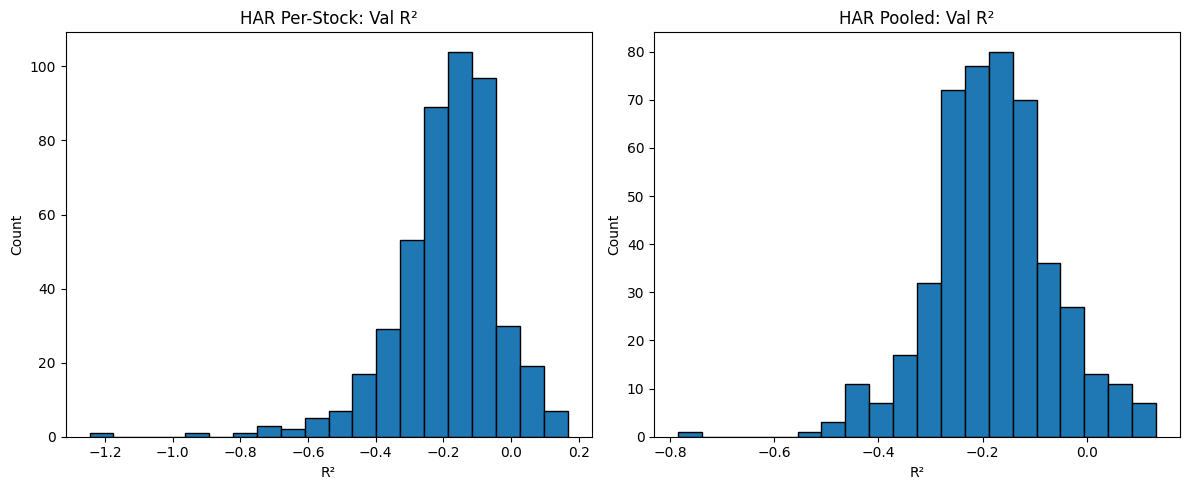

Per-stock R²: median=-0.167  mean=-0.189
Pooled    R²: median=-0.185  mean=-0.180


In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

har_r2  = [r2_score(target_val[t].values, har_val_df[t].values) for t in tickers]
pool_r2 = [r2_score(target_val[t].values, har_pooled_val_df[t].values) for t in tickers]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(har_r2,  bins=20, edgecolor="k")
axes[0].set_title("HAR Per-Stock: Val R²")
axes[0].set_xlabel("R²"); axes[0].set_ylabel("Count")
axes[1].hist(pool_r2, bins=20, edgecolor="k")
axes[1].set_title("HAR Pooled: Val R²")
axes[1].set_xlabel("R²"); axes[1].set_ylabel("Count")
plt.tight_layout(); plt.show()
print(f"Per-stock R²: median={np.median(har_r2):.3f}  mean={np.mean(har_r2):.3f}")
print(f"Pooled    R²: median={np.median(pool_r2):.3f}  mean={np.mean(pool_r2):.3f}")

In [9]:
results_dir = Path(config.DATA_RESULTS_DIR)
results_dir.mkdir(parents=True, exist_ok=True)

assert har_val_df.shape       == (num_val_weeks, num_stocks), f"Shape error: {har_val_df.shape}"
assert har_pooled_val_df.shape == (num_val_weeks, num_stocks), f"Shape error: {har_pooled_val_df.shape}"

har_val_df.to_parquet(results_dir / "har_val_preds.parquet")
har_pooled_val_df.to_parquet(results_dir / "har_pooled_val_preds.parquet")
print(f"Saved har_val_preds.parquet and har_pooled_val_preds.parquet → {results_dir}/")

Saved har_val_preds.parquet and har_pooled_val_preds.parquet → C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results/


## LSTM Baseline

In [10]:
import json
import numpy as np
import pandas as pd
import torch
from pathlib import Path

# Load features.parquet and reconstruct 3D tensor aligned to target's index
meta         = json.load(open(Path(config.DATA_FEATURES_DIR) / "features_meta.json"))
feature_names = meta["feature_names"]
feat_df       = pd.read_parquet(Path(config.DATA_FEATURES_DIR) / "features.parquet")
feat_df["week"] = pd.to_datetime(feat_df["week"])

# Drop the one extra week that has no target (features covers 573 weeks, target 572)
feat_df = feat_df[feat_df["week"].isin(target.index)].copy()

# Sort rows to match target column order (stocks) and target.index order (weeks)
ticker_order      = {t: i for i, t in enumerate(tickers)}
feat_df["_ord"]   = feat_df["ticker"].map(ticker_order)
feat_df           = feat_df.sort_values(["week", "_ord"]).drop(columns="_ord")

n_weeks  = target.shape[0]    # 572
n_stocks = target.shape[1]    # 50
n_feats  = len(feature_names) # 10

features_3d = feat_df[feature_names].values.reshape(n_weeks, n_stocks, n_feats)
target_arr  = target.values  # (572, 50)

assert features_3d.shape == (n_weeks, n_stocks, n_feats), f"Shape error: {features_3d.shape}"
assert target_arr.shape  == (n_weeks, n_stocks),          f"Shape error: {target_arr.shape}"
print(f"features_3d: {features_3d.shape}  target_arr: {target_arr.shape}")

features_3d: (572, 465, 10)  target_arr: (572, 465)


In [11]:
# Map week timestamps to integer row positions in features_3d / target_arr
week_to_pos = {w: i for i, w in enumerate(target.index)}

train_pos = np.sort([week_to_pos[w] for w in splits.loc[splits["split"] == "train", "week"]
                     if w in week_to_pos])
val_pos   = np.sort([week_to_pos[w] for w in splits.loc[splits["split"] == "val",   "week"]
                     if w in week_to_pos])

print(f"train_pos: {len(train_pos)} weeks  (first={train_pos[0]}, last={train_pos[-1]})")
print(f"val_pos:   {len(val_pos)}  weeks  (first={val_pos[0]},  last={val_pos[-1]})")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

_ckpt_path = Path(config.CHECKPOINTS_DIR) / "lstm_best.pt"
_loss_path = Path(config.DATA_RESULTS_DIR) / "lstm_val_loss.json"

if _ckpt_path.exists() and _loss_path.exists():
    print("lstm_best.pt found — skipping training.")
    set_seeds()
    lstm = LSTMModel(input_size=n_feats).to(device)
    lstm.load_state_dict(torch.load(_ckpt_path, map_location=device, weights_only=True))
    _loss_data    = json.load(open(_loss_path))
    val_loss_hist = _loss_data["val_loss"]
    print(f"Best val MSE: {_loss_data['best_val_loss']:.6f}")
else:
    set_seeds()
    lstm = LSTMModel(input_size=n_feats).to(device)
    lstm, val_loss_hist = train_lstm(lstm, features_3d, target_arr, train_pos, val_pos, device)
    print(f"\nTraining complete. Best val loss: {min(val_loss_hist):.6f}")

train_pos: 417 weeks  (first=0, last=416)
val_pos:   52  weeks  (first=417,  last=468)
Device: cuda
lstm_best.pt found — skipping training.
Best val MSE: 0.020786


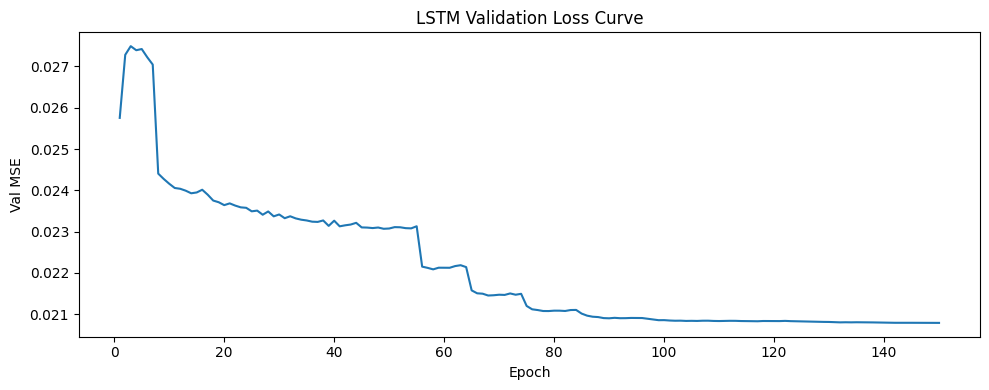

Best val MSE: 0.020786 at epoch 150


In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(val_loss_hist) + 1), val_loss_hist, linewidth=1.5)
plt.xlabel("Epoch")
plt.ylabel("Val MSE")
plt.title("LSTM Validation Loss Curve")
plt.tight_layout()
plt.show()

best_epoch = int(np.argmin(val_loss_hist)) + 1
print(f"Best val MSE: {min(val_loss_hist):.6f} at epoch {best_epoch}")

In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Generate val predictions from the best checkpoint.
# Mirror the training loop's NaN handling: zero-fill stocks with NaN features,
# then mark their predictions as NaN so they are excluded from metrics.
lstm.eval()
preds_list   = []
used_val_pos = [p for p in val_pos if p >= config.LSTM_SEQ_LEN - 1]

with torch.no_grad():
    for p in used_val_pos:
        seq       = features_3d[p - config.LSTM_SEQ_LEN + 1 : p + 1]
        stock_nan = np.isnan(seq).any(axis=(0, 2))   # (num_stocks,) — True where any NaN in window
        seq_clean = seq.copy()
        seq_clean[:, stock_nan, :] = 0.0
        x    = torch.tensor(seq_clean, dtype=torch.float32).permute(1, 0, 2).to(device)
        pred = lstm(x).cpu().numpy()                 # (num_stocks,)
        pred[stock_nan] = np.nan                     # exclude NaN-feature stocks from metrics
        preds_list.append(pred)

lstm_val_df = pd.DataFrame(
    np.stack(preds_list),
    index=target.index[used_val_pos],
    columns=tickers,
)
assert lstm_val_df.shape == (len(used_val_pos), n_stocks), f"Shape error: {lstm_val_df.shape}"

target_val_lstm = target.loc[lstm_val_df.index]

t_flat = target_val_lstm.values.ravel()
p_flat = lstm_val_df.values.ravel()
valid  = ~(np.isnan(t_flat) | np.isnan(p_flat))
lstm_mse = mean_squared_error(t_flat[valid], p_flat[valid])
lstm_mae = mean_absolute_error(t_flat[valid], p_flat[valid])
print(f"LSTM — Val MSE: {lstm_mse:.6f}  MAE: {lstm_mae:.6f}")
print(f"HAR per-stock  — Val MSE: {har_mse:.6f}")
print(f"HAR pooled     — Val MSE: {pool_mse:.6f}")

lstm_val_df.to_parquet(Path(config.DATA_RESULTS_DIR) / "lstm_val_preds.parquet")
print(f"\nSaved lstm_val_preds.parquet  shape={lstm_val_df.shape}")

LSTM — Val MSE: 0.020786  MAE: 0.098701
HAR per-stock  — Val MSE: 0.021841
HAR pooled     — Val MSE: 0.021951

Saved lstm_val_preds.parquet  shape=(52, 465)


## Experiment registry reference

Current training and evaluation artifacts should be registered before downstream comparison.

In [1]:
# REGISTRY_REFERENCE_CELL
from pathlib import Path
import pandas as pd
from IPython.display import display

registry_path = Path('../data/results/experiment_registry.csv')
registry = pd.read_csv(registry_path)
display(registry[['experiment_id', 'model_name', 'feature_version', 'graph_version', 'checkpoint_path']])
print(f'Registry path: {registry_path.as_posix()}')


experiment_id,model_name,feature_version,graph_version,checkpoint_path
baseline_har_per_stock,HAR per-stock,har_realized_volatility_lags_v1,none,NaN
baseline_har_pooled,HAR pooled,har_realized_volatility_lags_v1,none,NaN
baseline_lstm,LSTM,stock_features_v1,none,data/results/checkpoints/lstm_best.pt
baseline_gnn_correlation,GNN-Correlation,stock_features_v1,correlation_threshold_0.3_lookback_252,data/results/checkpoints/gnn_corr_best.pt
baseline_gnn_sector,GNN-Sector,stock_features_v1,sector_yfinance_labels_v1,data/results/checkpoints/gnn_sector_best.pt
baseline_gnn_granger,GNN-Granger,stock_features_v1,granger_lag_5_bonferroni,data/results/checkpoints/gnn_granger_best.pt
baseline_gnn_ensemble,GNN-Ensemble,stock_features_v1,correlation+sector+granger_v1,NaN
rankloss_gnn_correlation,Rank-loss GNN-Correlation,stock_features_v1,correlation_threshold_0.3_lookback_252,data/results/checkpoints/gnn_corr_rankloss_best.pt
rankloss_gnn_sector,Rank-loss GNN-Sector,stock_features_v1,sector_yfinance_labels_v1,data/results/checkpoints/gnn_sector_rankloss_best.pt
rankloss_gnn_granger,Rank-loss GNN-Granger,stock_features_v1,granger_lag_5_bonferroni,data/results/checkpoints/gnn_granger_rankloss_best.pt


Registry path: ../data/results/experiment_registry.csv


## Directional Accuracy

In [14]:
# Directional accuracy: for each (stock, week), did the model correctly predict
# whether RV(T+1) would be higher or lower than RV(T)?
#
# current_rv[i, T] = actual RV of week T (last known value at prediction time)
# actual_up[i, T]  = True if RV(T+1) > RV(T)
# pred_up[i, T]    = True if model's predicted RV(T+1) > RV(T)
# DA               = mean(pred_up == actual_up) over all (stock, week) pairs

val_weeks = har_val_df.index  # 52-week DatetimeIndex; LSTM covers the same weeks

current_rv  = weekly_rv.loc[val_weeks, tickers]          # RV of week T
actual_rv   = target.loc[val_weeks, tickers]             # RV of week T+1 (ground truth)
actual_up   = (actual_rv > current_rv)                   # (52, 50) bool DataFrame

pct_up = actual_up.values.mean()
print(f"Base rate: vol actually went UP in {pct_up:.1%} of (stock, week) pairs\n")

def directional_accuracy(pred_df: pd.DataFrame) -> float:
    pred_up = (pred_df > current_rv)
    return float((pred_up == actual_up).values.mean())

har_da  = directional_accuracy(har_val_df)
pool_da = directional_accuracy(har_pooled_val_df)
lstm_da = directional_accuracy(lstm_val_df)

print(f"Directional accuracy — pooled over all stocks and val weeks:")
print(f"  HAR per-stock : {har_da:.4f}")
print(f"  HAR pooled    : {pool_da:.4f}")
print(f"  LSTM          : {lstm_da:.4f}")

Base rate: vol actually went UP in 49.4% of (stock, week) pairs

Directional accuracy — pooled over all stocks and val weeks:
  HAR per-stock : 0.7130
  HAR pooled    : 0.7061
  LSTM          : 0.7125


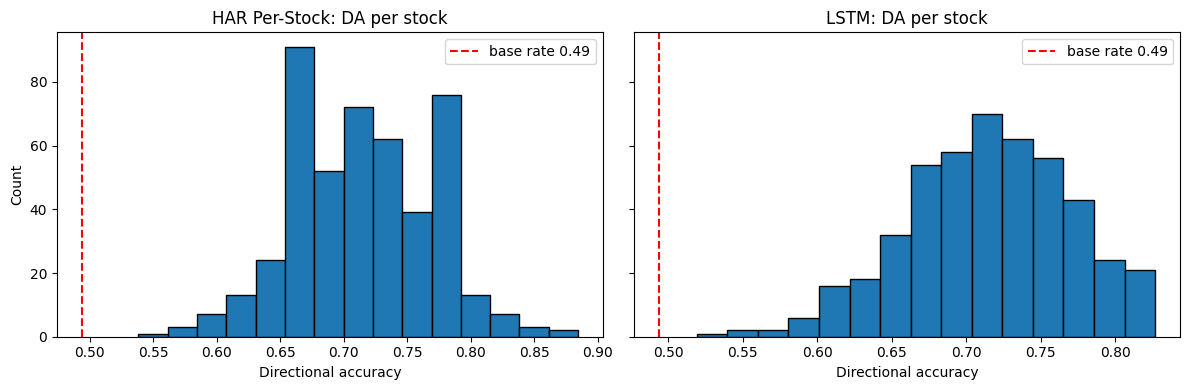

HAR per-stock  DA — median: 0.7115  min: 0.5385  max: 0.8846
LSTM           DA — median: 0.7115  min: 0.5192  max: 0.8269


In [15]:
# Per-stock DA distribution: how consistent is directional accuracy across stocks?
import matplotlib.pyplot as plt

def per_stock_da(pred_df: pd.DataFrame) -> pd.Series:
    pred_up = (pred_df > current_rv)
    return (pred_up == actual_up).mean(axis=0)   # mean over weeks, one value per stock

har_da_by_stock  = per_stock_da(har_val_df)
lstm_da_by_stock = per_stock_da(lstm_val_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].hist(har_da_by_stock,  bins=15, edgecolor="k")
axes[0].axvline(pct_up, color="red", linestyle="--", label=f"base rate {pct_up:.2f}")
axes[0].set_title("HAR Per-Stock: DA per stock")
axes[0].set_xlabel("Directional accuracy"); axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].hist(lstm_da_by_stock, bins=15, edgecolor="k")
axes[1].axvline(pct_up, color="red", linestyle="--", label=f"base rate {pct_up:.2f}")
axes[1].set_title("LSTM: DA per stock")
axes[1].set_xlabel("Directional accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"HAR per-stock  DA — median: {har_da_by_stock.median():.4f}  "
      f"min: {har_da_by_stock.min():.4f}  max: {har_da_by_stock.max():.4f}")
print(f"LSTM           DA — median: {lstm_da_by_stock.median():.4f}  "
      f"min: {lstm_da_by_stock.min():.4f}  max: {lstm_da_by_stock.max():.4f}")